In [1]:
!pip install pandas numpy matplotlib

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ----------- ---------------------------- 2.9/10.0 MB 25.3 MB/s eta 0:00:01
   ----------------------------------- ---- 8.9/10.0 MB 26.9 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 22.8 MB/s  0:00:00

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   ----------

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed so all students get the exact same random numbers
np.random.seed(42)

# 1. Create an array of 100 days (Day 1 to 100)
days = np.arange(1, 101)
print(days)

# 2. Simulate 100 days of Temperatures (Average 75 degrees, standard deviation of 10)
temperatures = np.random.normal(loc=75, scale=10, size=100)
temperatures = np.round(temperatures, 1) # Round to 1 decimal place

# 3. Simulate Sales (Ice cream goes up when it's hot, coffee goes down)
# Add a little random noise so the data doesn't look completely artificial
ice_cream_sales = (temperatures * 4) + np.random.normal(0, 20, 100)
coffee_sales = (400 - (temperatures * 3)) + np.random.normal(0, 15, 100)

# Clean up negative sales (can't sell less than 0 items)
ice_cream_sales = np.maximum(ice_cream_sales, 0)
coffee_sales = np.maximum(coffee_sales, 0)

print(f"First 5 temperatures: {temperatures[:5]}")
print(f"First 5 days of ice cream sales: {ice_cream_sales[:5]}")
print(f"First 5 days of coffee sales: {coffee_sales[:5]}")


[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
First 5 temperatures: [80.  73.6 81.5 90.2 72.7]
First 5 days of ice cream sales: [291.69258516 285.98709354 319.14570967 344.75445462 287.57428577]
First 5 days of coffee sales: [165.36681041 187.6117679  171.74576865 145.20703078 161.23495948]


In [8]:
# 1. Create the DataFrame to organize our arrays into columns
df = pd.DataFrame({
    'Day': days,
    'Temperature': temperatures,
    'Ice_Cream': np.round(ice_cream_sales),
    'Coffee': np.round(coffee_sales)
})

# 2. Basic Exploration 
print(df.head())
newdf = df.describe()
print(newdf)
print(newdf ["Day"]["mean"])

# 3. Feature Engineering: Create a new column for Total Items Sold
df['Total_Sales'] = df['Ice_Cream'] + df['Coffee']

# 4. Data Filtering: Let's analyze "Heatwave" days (over 85 degrees)
heatwave_df = df[df['Temperature'] > 85]

# Find the single day with the highest total sales
best_day = df[df['Total_Sales'] == df['Total_Sales'].max()]

print("Our Best Sales Day:")
print(best_day)

   Day  Temperature  Ice_Cream  Coffee
0    1         80.0      292.0   165.0
1    2         73.6      286.0   188.0
2    3         81.5      319.0   172.0
3    4         90.2      345.0   145.0
4    5         72.7      288.0   161.0
              Day  Temperature   Ice_Cream      Coffee
count  100.000000   100.000000  100.000000  100.000000
mean    50.500000    73.963000  296.290000  179.050000
std     29.011492     9.080934   38.643748   28.979747
min      1.000000    48.800000  201.000000  107.000000
25%     25.750000    69.000000  273.000000  160.750000
50%     50.500000    73.700000  292.500000  182.000000
75%     75.250000    79.100000  318.250000  196.250000
max    100.000000    93.500000  401.000000  242.000000
50.5
Our Best Sales Day:
    Day  Temperature  Ice_Cream  Coffee  Total_Sales
20   21         89.7      375.0   166.0        541.0


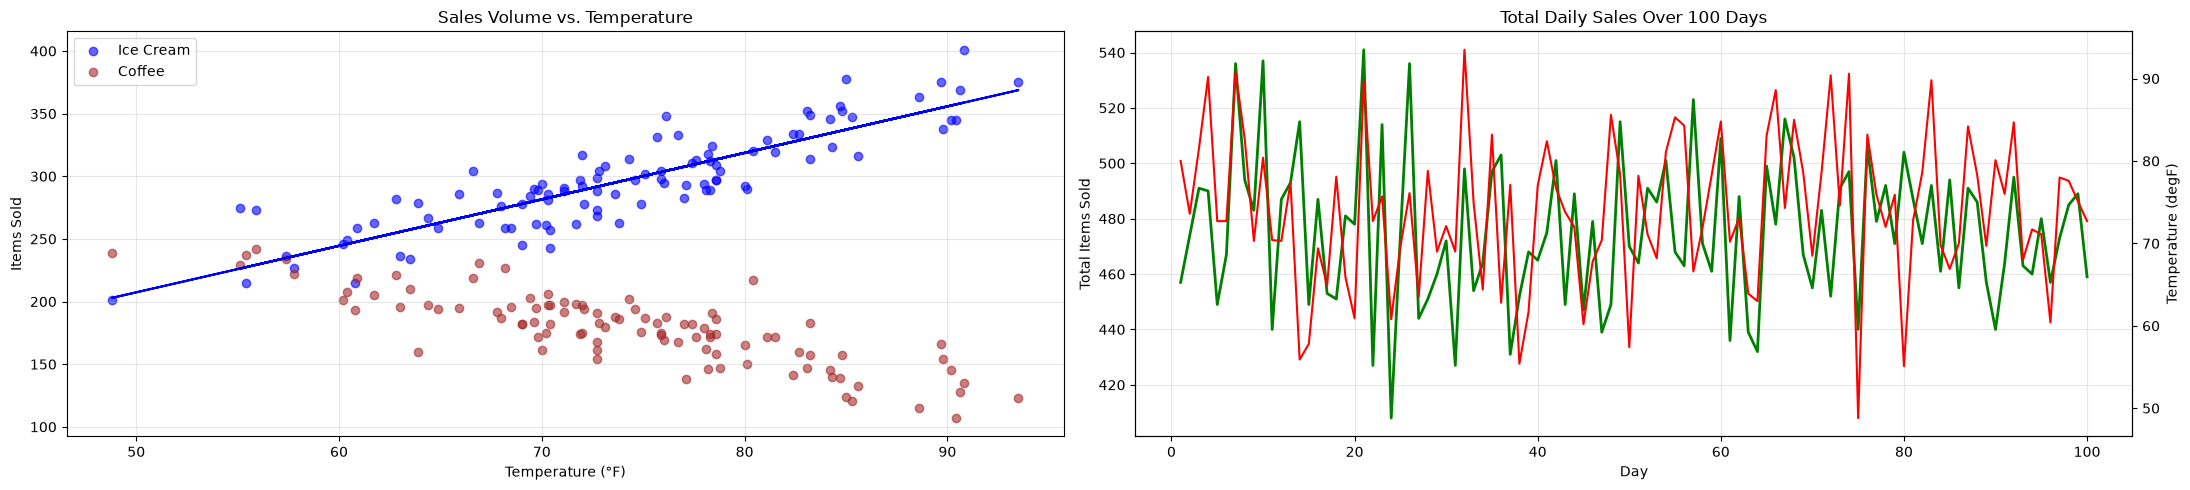

In [18]:
# Create a figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 5))

# --- Plot 1: Scatter Plot (Correlation) ---
# Does temperature really affect sales? Let's prove it visually.
ax1.scatter(df['Temperature'], df['Ice_Cream'], color='blue', alpha=0.6, label='Ice Cream')
ax1.scatter(df['Temperature'], df['Coffee'], color='brown', alpha=0.6, label='Coffee')
ax1.set_title('Sales Volume vs. Temperature')
ax1.set_xlabel('Temperature (°F)')
ax1.set_ylabel('Items Sold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Line Graph (Trends over Time) ---
# How did our total sales look over the 100 days?
ax2.plot(df['Day'], df['Total_Sales'], color='green', linewidth=2)
ax2.set_title('Total Daily Sales Over 100 Days')
ax2.set_xlabel('Day')
ax2.set_ylabel('Total Items Sold')
ax2.grid(True, alpha=0.3)
ax3 = ax2.twinx()
ax3.set_ylabel('Temperature (degF)')
ax3.plot(df['Day'], df['Temperature'], color = 'red')

coefficients = np.polyfit(df['Temperature'],df['Ice_Cream'],1)
polynomial = np.poly1d(coefficients)
trend_line = polynomial(df['Temperature'])
ax1.plot(df['Temperature'], trend_line, color="blue")



# Display the graphs cleanly
plt.tight_layout()
plt.show()